# CNN전이학습
* 전이학습: 사전에 훈련된 모델을 가져와서 사용하는 것
* data_augmentation: 이미지 데이터의 경우 데이터가 적어서 확보가 어렵고 비쌈. 기존 이미지데이터에 변형을 가해서 데이터 수를 늘리는 작업(회전, 확대, 축소, 자르기)

# Image Augmentation
* 학습데이터 부족을 해결하기 위해서 이미지에 변형을 가해 새로운 이미지를 만들어 주는 것

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img

In [8]:
image = load_img("./data/catanddog/bird.jpg")

# 이미지 배열로 변환
image_array = img_to_array(image)
print(image_array.shape)

(703, 454, 3)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

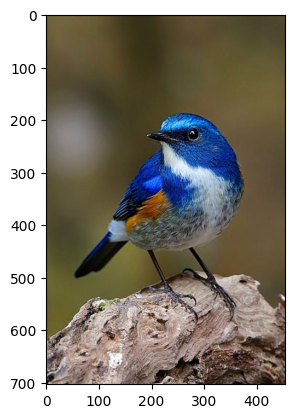

In [11]:
plt.imshow(image)
plt.show

# Image Augmentation(이미지 증폭)

In [12]:
imggen=ImageDataGenerator(rescale=1./255, rotation_range=40, width_shift_range=0.3, 
                         height_shift_range=0.2, shear_range=0.6, zoom_range=0.3,
                          horizontal_flip=True, vertical_flip=True, fill_mode='nearest')

In [13]:
image_array.shape

(703, 454, 3)

In [14]:
image_array.reshape((1,)+image_array.shape).shape

(1, 703, 454, 3)

In [15]:
image_array=image_array.reshape((1,)+image_array.shape)
image_array.shape


(1, 703, 454, 3)

AttributeError: module 'matplotlib.pyplot' has no attribute 'title_layout'

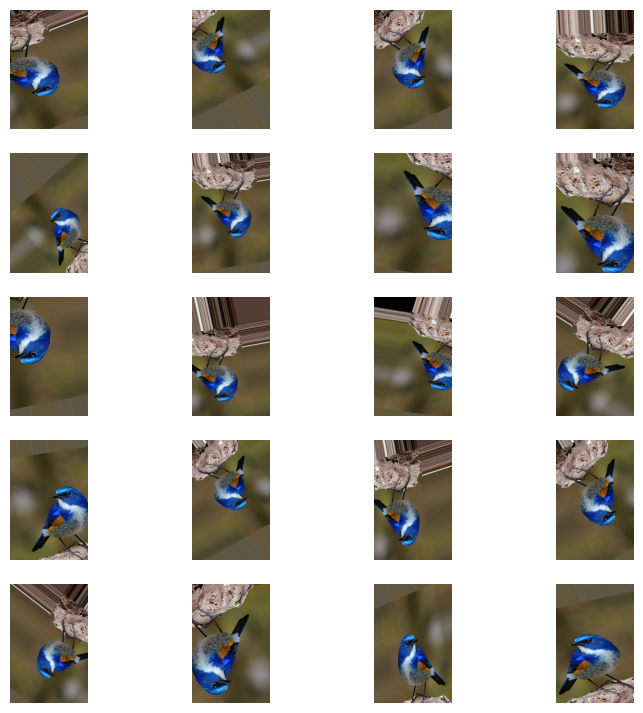

In [16]:
fig, axes= plt.subplots(5,4, figsize=(9,9))
axes=axes.ravel()

for i, batch in enumerate(imggen.flow(image_array, batch_size=1)):
    if i >= 20:
        break
    augmented_image=array_to_img(batch[0])
    axes[i].imshow(augmented_image)
    axes[i].axis('off')
plt.title_layout()
plt.show()

# image_augmentation을 이용한 개/고양이 분류모델 만들기

In [17]:
# 데이터 로드
train_dir="./data/catanddog/train/"
valid_dir='./data/catanddog/validation/'
batch_size=16 # 한 번에 불러오는 사진의 개수, 분석 모델에 따라서 16~32 사이로 지정
image_size=(224, 224) # 모델의 입력 크기에 맞춤


In [18]:
# 이미지 증강
train_aug=ImageDataGenerator(
rescale=1./255, rotation_range=40, width_shift_range=0.3, height_shift_range=0.2,
shear_range=0.6, zoom_range=0.3, fill_mode='nearest')

valid_aug= ImageDataGenerator(rescale=1./255)

# 이미지 제너레이터
train_gen = train_aug.flow_from_directory(train_dir, target_size=image_size,
                                         batch_size=batch_size, class_mode='categorical', shuffle=True, seed=42)

valid_gen=valid_aug.flow_from_directory(
valid_dir, target_size=image_size,
batch_size=batch_size, class_mode='categorical', shuffle=True, seed=42)

X_batch, y_batch= next(train_gen)
print(X_batch.shape)
print(y_batch.shape)
print(train_gen.class_indices)

Found 2222 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


# CNN을 이용한 개/고양이 분류

In [19]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [21]:
cnn_model= Sequential()
cnn_model.add(Input(shape=(224,224,3)))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(2, activation='softmax'))
cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,815,266 (10.74 MB)

 Trainable params: 2,815,266 (10.74 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
import tensorflow as tf

In [24]:
cnn_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                 metrics=['accuracy'])
model_path="./model/cnn_catndog.keras"
check_point=ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop=EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
cnn_history=cnn_model.fit(train_gen, epochs=1000, validation_data=valid_gen, callbacks=[early_stop, check_point])
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/1000


I0000 00:00:1747709066.839537      88 service.cc:146] XLA service 0x7fbd58014120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747709066.839620      88 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-20 02:44:26.906922: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-20 02:44:27.261823: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
E0000 00:00:1747709070.569515      88 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747709070.803848      88 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E00

  2/139 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.3438 - loss: 0.7341  

I0000 00:00:1747709075.008579      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.4816 - loss: 0.7047
Epoch 1: val_loss improved from inf to 0.68794, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 109s 718ms/step - accuracy: 0.4817 - loss: 0.7046 - val_accuracy: 0.5000 - val_loss: 0.6879
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5052 - loss: 0.6921
Epoch 2: val_loss improved from 0.68794 to 0.68485, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 45s 320ms/step - accuracy: 0.5052 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6848
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.5272 - loss: 0.6949
Epoch 3: val_loss improved from 0.68485 to 0.67756, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 44s 317ms/step - accuracy: 0.5272 - loss: 0.6949 - val_accuracy: 0.5102 - val_loss: 0.6776
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.5438 - loss: 0.6883
Epoch 4: val_l

Epoch 25/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.6591 - loss: 0.6167
Epoch 25: val_loss did not improve from 0.55769
139/139 ━━━━━━━━━━━━━━━━━━━━ 44s 313ms/step - accuracy: 0.6592 - loss: 0.6167 - val_accuracy: 0.7041 - val_loss: 0.5637
Epoch 26/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.6728 - loss: 0.6108
Epoch 26: val_loss did not improve from 0.55769
139/139 ━━━━━━━━━━━━━━━━━━━━ 54s 385ms/step - accuracy: 0.6728 - loss: 0.6107 - val_accuracy: 0.7041 - val_loss: 0.5708
Epoch 27/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6685 - loss: 0.6147
Epoch 27: val_loss did not improve from 0.55769
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 363ms/step - accuracy: 0.6685 - loss: 0.6147 - val_accuracy: 0.5816 - val_loss: 0.6896
Epoch 28/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6679 - loss: 0.6157
Epoch 28: val_loss did not improve from 0.55769
139/139 ━━━━━━━━━━━━━━━━━━━━ 43s 308ms/step - accuracy: 0.6679 - loss: 0.6157 - val_

Epoch 50/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.7325 - loss: 0.5410
Epoch 50: val_loss did not improve from 0.50203
139/139 ━━━━━━━━━━━━━━━━━━━━ 78s 558ms/step - accuracy: 0.7324 - loss: 0.5410 - val_accuracy: 0.7245 - val_loss: 0.5404
Epoch 51/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.7240 - loss: 0.5497
Epoch 51: val_loss did not improve from 0.50203
139/139 ━━━━━━━━━━━━━━━━━━━━ 76s 548ms/step - accuracy: 0.7239 - loss: 0.5498 - val_accuracy: 0.7347 - val_loss: 0.5453
Epoch 52/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.7278 - loss: 0.5496
Epoch 52: val_loss did not improve from 0.50203
139/139 ━━━━━━━━━━━━━━━━━━━━ 85s 608ms/step - accuracy: 0.7278 - loss: 0.5496 - val_accuracy: 0.7245 - val_loss: 0.5519
Epoch 53/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7445 - loss: 0.5300
Epoch 53: val_loss did not improve from 0.50203
139/139 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.7444 - loss: 0.5300 - val_accur

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.7310 - loss: 0.5254
Epoch 75: val_loss improved from 0.47683 to 0.47577, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 45s 319ms/step - accuracy: 0.7311 - loss: 0.5253 - val_accuracy: 0.7347 - val_loss: 0.4758
Epoch 76/1000
 40/139 ━━━━━━━━━━━━━━━━━━━━ 30s 313ms/step - accuracy: 0.7340 - loss: 0.5166

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step


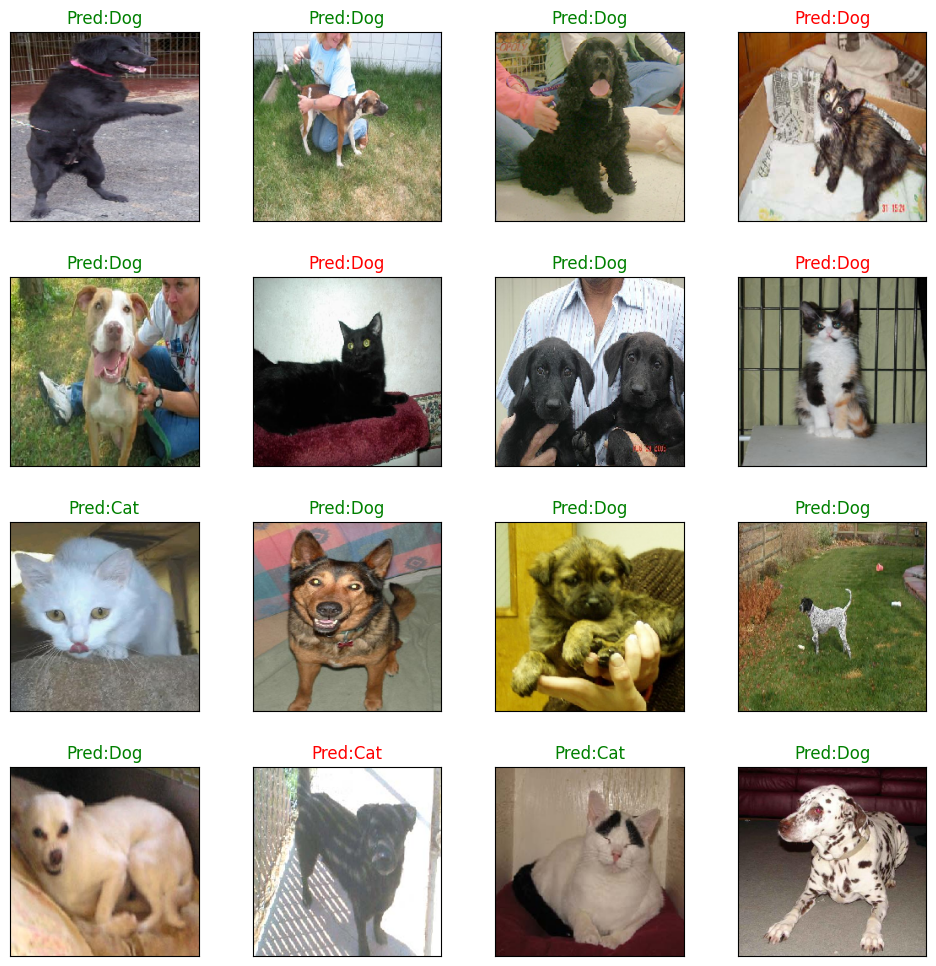


cnn_best_model 평가 결과: Loss: 0.4457, Accuracy:0.7500


In [26]:
# best 모델 로드
cnn_best_model=load_model("./model/cnn_catndog.keras")

# 클래스 이름 추출하기
class_indices=valid_gen.class_indices
class_names=[k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch=next(iter(valid_gen))

cnn_pred=cnn_best_model.predict(validation_batch)
pred_values=np.argmax(cnn_pred, axis=1)
true_values=np.argmax(label_batch, axis=1)

fig=plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images=min(16, validation_batch.shape[0])

for i in range(num_images):
    ax=fig.add_subplot(4,4,i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label=class_names[pred_values[i]]
    true_label=class_names[true_values[i]]
    color='green' if pred_values[i]==true_values[i] else 'red'
    ax.set_title(f"Pred:{pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc=cnn_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\ncnn_best_model 평가 결과: Loss: {loss:.4f}, Accuracy:{acc:.4f}")

# 전이학습
* 사전에 훈련된 모델을 가지고 새로운 데이터를 넣어서 튜닝을 하거나 결과를 출력
* keras.applications에 있음


# ResNet50

In [31]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, ResNet152V2

In [32]:
base_model=ResNet50(
include_top=False,
weights='imagenet',
input_tensor=None,
input_shape=(224,224,3),
pooling='avg')

In [33]:
base_model.trainable=False
res50_model=Sequential()
res50_model.add(base_model)
res50_model.add(Dense(2, activation='softmax'))
res50_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [34]:
res50_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                 metrics=['accuracy'])
model_path="./model/res50_catndog.keras"
check_point=ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop=EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
res50_history=res50_model.fit(train_gen, epochs=1000, validation_data=valid_gen, callbacks=[early_stop, check_point])
plt.plot(res50_history.history['loss'])
plt.plot(res50_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

Epoch 1/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.4975 - loss: 0.8267
Epoch 1: val_loss improved from inf to 0.69334, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.4975 - loss: 0.8261 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - accuracy: 0.4948 - loss: 0.6938
Epoch 2: val_loss improved from 0.69334 to 0.69198, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.4948 - loss: 0.6938 - val_accuracy: 0.5102 - val_loss: 0.6920
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5119 - loss: 0.6928
Epoch 3: val_loss improved from 0.69198 to 0.69144, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.5119 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6914
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5097 - loss: 0.6934
Epoch 4:

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5230 - loss: 0.6869
Epoch 24: val_loss did not improve from 0.67757
139/139 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.5231 - loss: 0.6869 - val_accuracy: 0.6020 - val_loss: 0.6781
Epoch 25/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.5415 - loss: 0.6863
Epoch 25: val_loss did not improve from 0.67757
139/139 ━━━━━━━━━━━━━━━━━━━━ 129s 930ms/step - accuracy: 0.5415 - loss: 0.6863 - val_accuracy: 0.5510 - val_loss: 0.6784
Epoch 26/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 942ms/step - accuracy: 0.5323 - loss: 0.6910
Epoch 26: val_loss did not improve from 0.67757
139/139 ━━━━━━━━━━━━━━━━━━━━ 135s 972ms/step - accuracy: 0.5323 - loss: 0.6910 - val_accuracy: 0.5510 - val_loss: 0.6796
Epoch 27/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.5238 - loss: 0.6890
Epoch 27: val_loss improved from 0.67757 to 0.67675, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


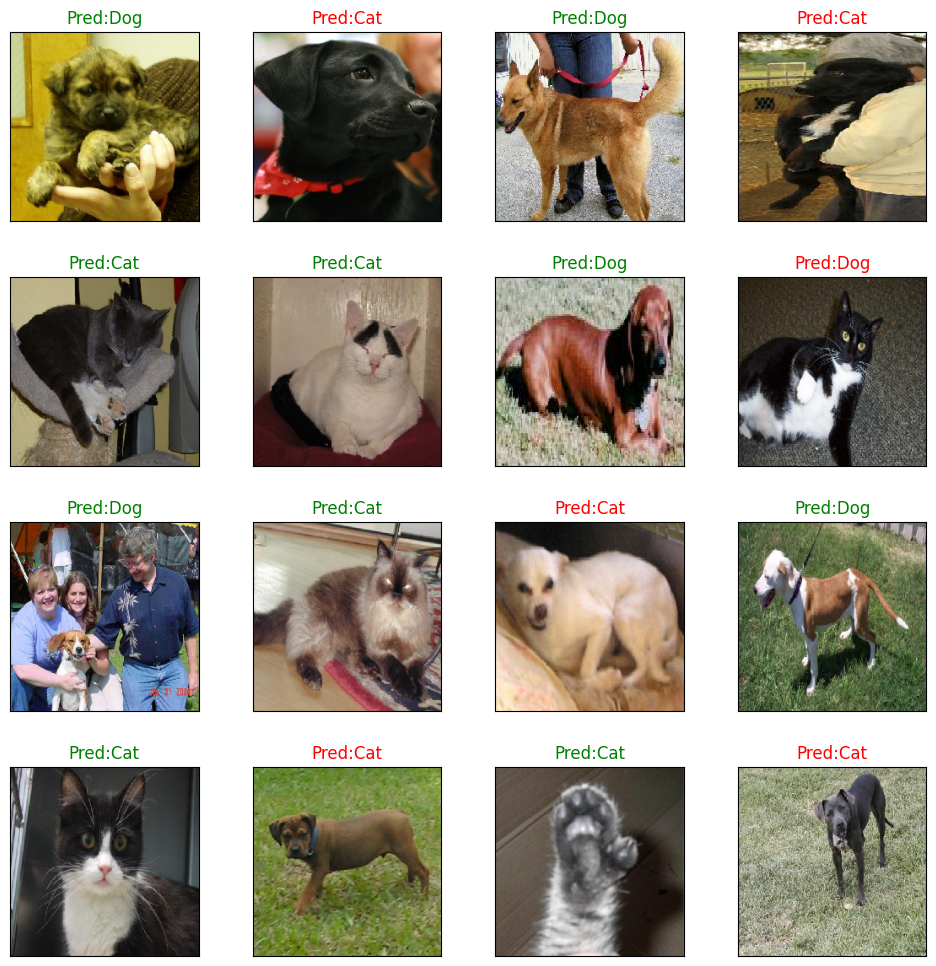


res50_best_model 평가 결과: Loss: 0.6885, Accuracy:0.6250


In [37]:
# best 모델 로드
res50_best_model=load_model("./model/res50_catndog.keras")

# 클래스 이름 추출하기
class_indices=valid_gen.class_indices
class_names=[k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch=next(iter(valid_gen))

cnn_pred=res50_best_model.predict(validation_batch)
pred_values=np.argmax(cnn_pred, axis=1)
true_values=np.argmax(label_batch, axis=1)

fig=plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images=min(16, validation_batch.shape[0])

for i in range(num_images):
    ax=fig.add_subplot(4,4,i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label=class_names[pred_values[i]]
    true_label=class_names[true_values[i]]
    color='green' if pred_values[i]==true_values[i] else 'red'
    ax.set_title(f"Pred:{pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc=res50_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres50_best_model 평가 결과: Loss: {loss:.4f}, Accuracy:{acc:.4f}")

# ResNet152V2

In [38]:
base_model2=ResNet152V2(
include_top=False,
weights='imagenet',
input_shape=(224,224,3),
pooling='avg')

In [39]:
base_model2.summary()

Model: "resnet152v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 58,331,648 (222.52 MB)

 Trainable params: 58,187,904 (221.97 MB)

 Non-trainable params: 143,744 (561.50 KB)

In [40]:
base_model2.trainable=False
res152v2_model=Sequential()
res152v2_model.add(base_model2)
res152v2_model.add(Dense(2, activation='softmax'))

In [41]:
res152v2_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                 metrics=['accuracy'])
model_path="./model/res152v2_catndog.keras"
check_point=ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop=EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
res152v2_history=res152v2_model.fit(train_gen, epochs=1000, validation_data=valid_gen, callbacks=[early_stop, check_point])
plt.plot(res152v2_history.history['loss'])
plt.plot(res152v2_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

Epoch 1/1000


2025-05-20 07:15:20.614023: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 676.06MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-20 07:15:21.938966: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 628.25MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-20 07:15:24.034801: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 629.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-20 07:15:25.307749: W external/local_tsl/tsl/framewor

102/139 ━━━━━━━━━━━━━━━━━━━━ 1:07 2s/step - accuracy: 0.7489 - loss: 0.5900

2025-05-20 07:18:56.408500: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 659.56MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-20 07:18:57.937480: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 619.75MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-20 07:18:59.980407: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 624.50MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-20 07:19:01.120311: W external/local_tsl/tsl/framewor

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7684 - loss: 0.5458
Epoch 1: val_loss improved from inf to 0.13825, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.7689 - loss: 0.5448 - val_accuracy: 0.9592 - val_loss: 0.1382
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8992 - loss: 0.2480
Epoch 2: val_loss improved from 0.13825 to 0.08233, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.8992 - loss: 0.2479 - val_accuracy: 0.9694 - val_loss: 0.0823
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9334 - loss: 0.1727
Epoch 3: val_loss improved from 0.08233 to 0.06037, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.9333 - loss: 0.1727 - val_accuracy: 0.9796 - val_loss: 0.0604
Epoch 4/1000
 96/139 ━━━━━━━━━━━━━━━━━━━━ 1:13 2s/step - accuracy: 0.9317 - loss: 0.1716

KeyboardInterrupt: 

In [ ]:
# best 모델 로드
res152v2_best_model=load_model("./model/res152v2_catndog.keras")

# 클래스 이름 추출하기
class_indices=valid_gen.class_indices
class_names=[k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch=next(iter(valid_gen))

cnn_pred=res152v2_best_model.predict(validation_batch)
pred_values=np.argmax(cnn_pred, axis=1)
true_values=np.argmax(label_batch, axis=1)

fig=plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images=min(16, validation_batch.shape[0])

for i in range(num_images):
    ax=fig.add_subplot(4,4,i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label=class_names[pred_values[i]]
    true_label=class_names[true_values[i]]
    color='green' if pred_values[i]==true_values[i] else 'red'
    ax.set_title(f"Pred:{pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc=res152v2_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres152v2_best_model 평가 결과: Loss: {loss:.4f}, Accuracy:{acc:.4f}")

# convnextbase로 분석하기

In [42]:
from tensorflow.keras.applications import ConvNeXtBase

In [43]:
base_model3=ConvNeXtBase(
    include_top=True,
    include_preprocessing=True,
    weights="imagenet",
    input_shape=(224,224,3),
    pooling='avg',
    classes=1000,
    classifier_activation="softmax",
    name="convnext_base",
)

355031056/355031056 ━━━━━━━━━━━━━━━━━━━━ 48s 0us/step


In [44]:
base_model3.trainable=False
ConvNeXtBase_model=Sequential()
ConvNeXtBase_model.add(base_model3)
ConvNeXtBase_model.add(Dense(2, activation='softmax'))

In [45]:
ConvNeXtBase_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                 metrics=['accuracy'])
model_path="./model/ConvNeXtBase_catndog.keras"
check_point=ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop=EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
ConvNeXtBase_history=ConvNeXtBase_model.fit(train_gen, epochs=1000, validation_data=valid_gen, callbacks=[early_stop, check_point])
plt.plot(ConvNeXtBase_history.history['loss'])
plt.plot(ConvNeXtBase_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

Epoch 1/1000
138/139 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4974 - loss: 0.6932

E0000 00:00:1747727108.371036      87 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747727108.593234      87 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747727108.770297      87 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4973 - loss: 0.6932
Epoch 1: val_loss improved from inf to 0.69299, saving model to ./model/ConvNeXtBase_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.4972 - loss: 0.6932 - val_accuracy: 0.5816 - val_loss: 0.6930
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5119 - loss: 0.6932
Epoch 2: val_loss improved from 0.69299 to 0.69290, saving model to ./model/ConvNeXtBase_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.5119 - loss: 0.6932 - val_accuracy: 0.6020 - val_loss: 0.6929
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5073 - loss: 0.6931
Epoch 3: val_loss improved from 0.69290 to 0.69280, saving model to ./model/ConvNeXtBase_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.5074 - loss: 0.6931 - val_accuracy: 0.5918 - val_loss: 0.6928
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5102 - loss: 0.6931
Epoch 

KeyboardInterrupt: 

In [ ]:
# best 모델 로드
ConvNeXtBase_best_model=load_model("./model/ConvNeXtBase_catndog.keras")

# 클래스 이름 추출하기
class_indices=valid_gen.class_indices
class_names=[k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch=next(iter(valid_gen))

cnn_pred=ConvNeXtBase_best_model.predict(validation_batch)
pred_values=np.argmax(cnn_pred, axis=1)
true_values=np.argmax(label_batch, axis=1)

fig=plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images=min(16, validation_batch.shape[0])

for i in range(num_images):
    ax=fig.add_subplot(4,4,i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label=class_names[pred_values[i]]
    true_label=class_names[true_values[i]]
    color='green' if pred_values[i]==true_values[i] else 'red'
    ax.set_title(f"Pred:{pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc=ConvNeXtBase_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nConvNeXtBase_best_model 평가 결과: Loss: {loss:.4f}, Accuracy:{acc:.4f}")